# ESG Exploratory Data Analysis

## Objectives

- Explore the cleaned ESG dataset.
- Analyse overall Environmental, Social, Governance and Total ESG performance.
- Compare ESG performance across industries and companies.
- Validate the project hypotheses using appropriate descriptive analysis and visualisations.
- Identify key insights to support the Power BI dashboard.


## Inputs

- `data/cleaned/esg_cleaned.csv`


## Outputs

- ESG analysis results and visualisations.
- Hypothesis validation results.
- Key insights for the Power BI dashboard.


## Additional Comments

- This notebook uses the cleaned dataset produced by the ETL notebook.


---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'c:\\CodeInstitute\\public_company_esg_analysis\\jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'c:\\CodeInstitute\\public_company_esg_analysis'

# Section 1

## Load Cleaned ESG Data


In [4]:
import pandas as pd

df = pd.read_csv("data/cleaned/esg_cleaned.csv")

df.head()


,ticker,name,currency,exchange,industry,environment_grade,environment_level,social_grade,social_level,governance_grade,governance_level,environment_score,social_score,governance_score,total_score,last_processing_date,total_grade,total_level,cik
0,dis,Walt Disney Co,USD,"NEW YORK STOCK EXCHANGE, INC.",Media,A,High,BB,Medium,BB,Medium,510,316,321,1147,2022-04-19,BBB,High,1744489
1,gm,General Motors Co,USD,"NEW YORK STOCK EXCHANGE, INC.",Automobiles,A,High,BB,Medium,B,Medium,510,303,255,1068,2022-04-17,BBB,High,1467858
2,gww,WW Grainger Inc,USD,"NEW YORK STOCK EXCHANGE, INC.",Trading Companies and Distributors,B,Medium,BB,Medium,B,Medium,255,385,240,880,2022-04-19,BB,Medium,277135
3,mhk,Mohawk Industries Inc,USD,"NEW YORK STOCK EXCHANGE, INC.",Consumer products,A,High,B,Medium,BB,Medium,570,298,303,1171,2022-04-18,BBB,High,851968
4,lyv,Live Nation Entertainment Inc,USD,"NEW YORK STOCK EXCHANGE, INC.",Media,BBB,High,BB,Medium,B,Medium,492,310,250,1052,2022-04-18,BBB,High,1335258


---

# Section 2

## Descriptive Statistics

This section examines the descriptive statistics of the main ESG score variables to understand their central tendency, range, and overall distribution.


In [5]:
score_columns = [
    "environment_score",
    "social_score",
    "governance_score",
    "total_score"
]

df[score_columns].describe()


,environment_score,social_score,governance_score,total_score
count,722.000000,722.000000,722.000000,722.000000
mean,404.806094,292.182825,278.761773,975.750693
std,145.103870,57.017406,47.031536,218.751796
min,200.000000,160.000000,75.000000,600.000000
25%,240.000000,243.000000,235.000000,763.000000
50%,483.000000,302.000000,300.000000,1046.000000
75%,518.750000,322.750000,310.000000,1144.000000
max,719.000000,667.000000,475.000000,1536.000000


In [6]:
df[score_columns].median()

environment_score     483.0
social_score          302.0
governance_score      300.0
total_score          1046.0
dtype: float64

### Descriptive Statistics Findings

- The dataset contains 722 companies with complete ESG score data.
- The average Environmental score is 404.81, with a median of 483.
- The average Social score is 292.18, with a median of 302.
- The average Governance score is 278.76, with a median of 300.
- The average Total ESG score is 975.75, with a median of 1046.
- Environmental scores show greater variability than Social and Governance scores, with a standard deviation of 145.10.
- For all four score measures, the median is higher than the mean, suggesting that lower scores may be pulling the averages downward.


### Distribution of ESG Scores

The distributions of the main ESG scores are examined to understand how company scores are spread and to identify potential skewness or unusual values.


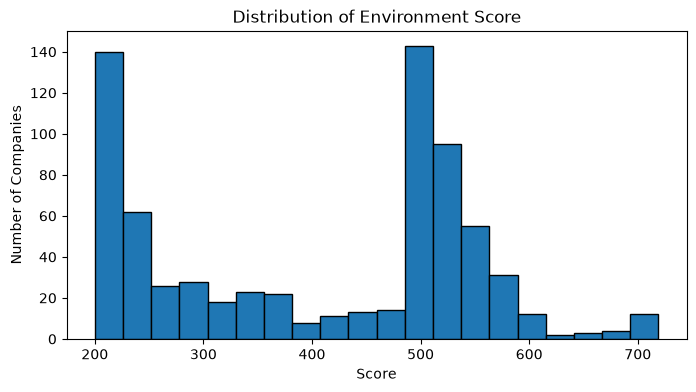

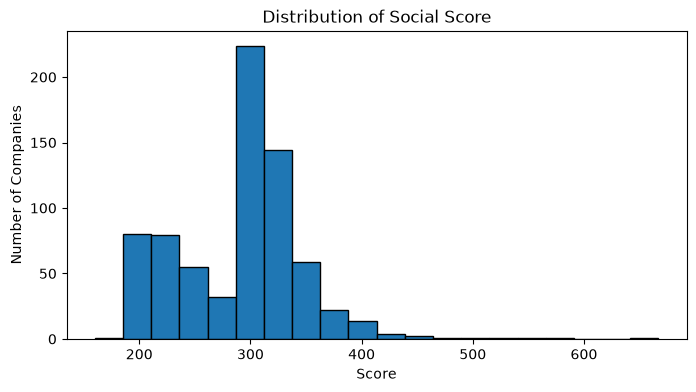

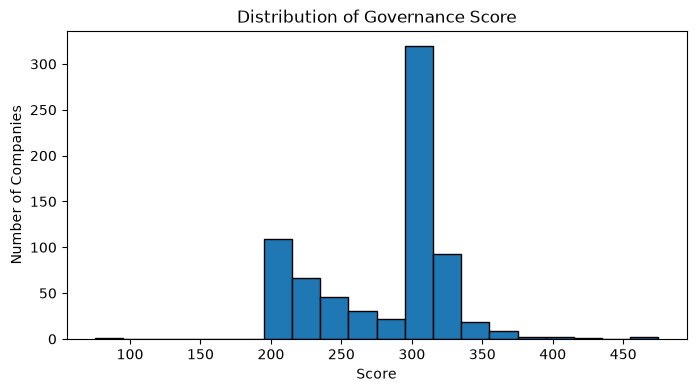

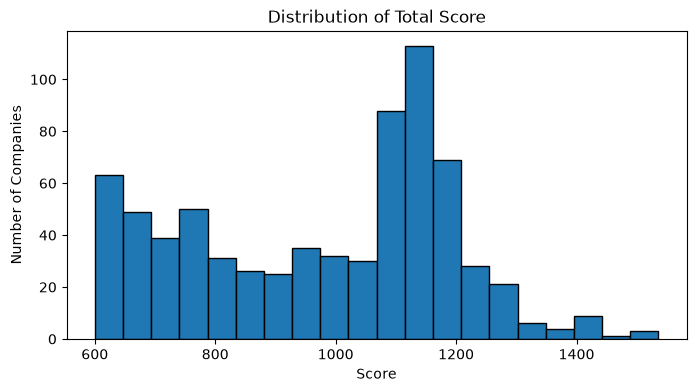

In [8]:
import matplotlib.pyplot as plt

for column in score_columns:
    plt.figure(figsize=(8, 4))
    plt.hist(df[column], bins=20, edgecolor="black")
    plt.title(f"Distribution of {column.replace('_', ' ').title()}")
    plt.xlabel("Score")
    plt.ylabel("Number of Companies")
    plt.show()


### Boxplots of ESG Scores

Boxplots are used to examine the spread of ESG scores and identify potential outliers.


C:\Users\lap-mohammadnejhad\AppData\Local\Temp\ipykernel_14620\2566052776.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[column], vert=False)


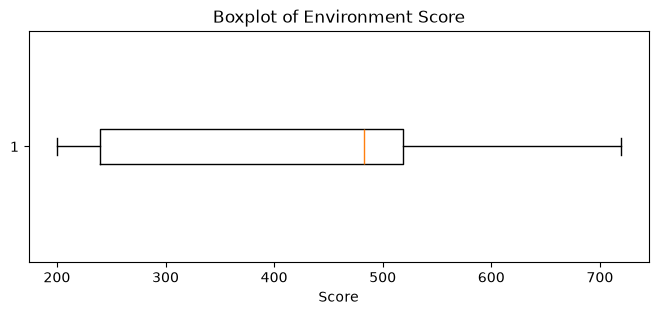

C:\Users\lap-mohammadnejhad\AppData\Local\Temp\ipykernel_14620\2566052776.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[column], vert=False)


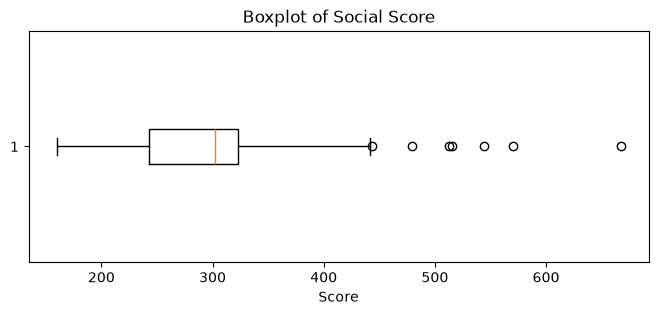

C:\Users\lap-mohammadnejhad\AppData\Local\Temp\ipykernel_14620\2566052776.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[column], vert=False)


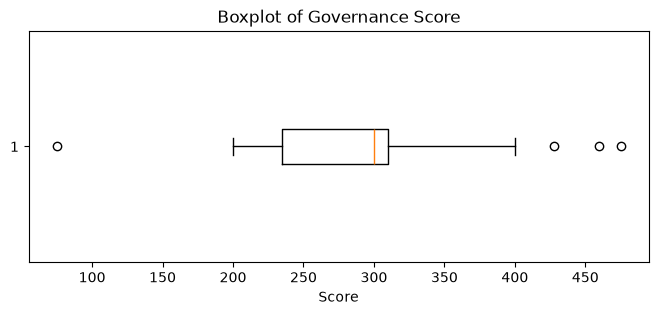

C:\Users\lap-mohammadnejhad\AppData\Local\Temp\ipykernel_14620\2566052776.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[column], vert=False)


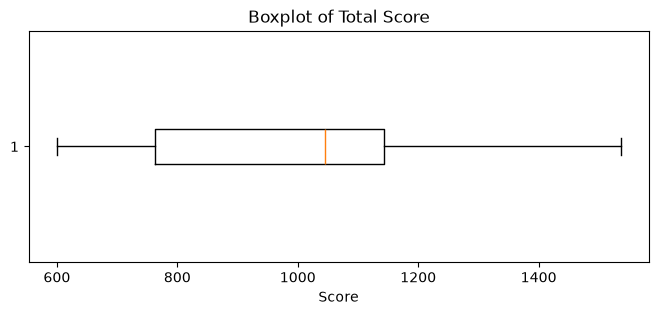

In [9]:
import matplotlib.pyplot as plt

for column in score_columns:
    plt.figure(figsize=(8, 3))
    plt.boxplot(df[column], vert=False)
    plt.title(f"Boxplot of {column.replace('_', ' ').title()}")
    plt.xlabel("Score")
    plt.show()


### Boxplot Findings

The boxplots show potential outliers in the Social and Governance scores, while the Environmental and Total scores show no clear outliers.

These values are retained because they may represent genuine differences in company ESG performance rather than data errors.


---

# Section 3

## ESG Score Comparison

This section compares the Environmental, Social, and Governance scores to identify differences in company performance across the three ESG dimensions.


In [10]:
esg_comparison = df[
    ["environment_score", "social_score", "governance_score"]
].agg(["mean", "median", "std", "min", "max"]).T

esg_comparison


,mean,median,std,min,max
environment_score,404.806094,483.0,145.103870,200.0,719.0
social_score,292.182825,302.0,57.017406,160.0,667.0
governance_score,278.761773,300.0,47.031536,75.0,475.0


### Comparison of ESG Score Distributions

The distributions of the three ESG dimensions are compared visually. Since the score ranges differ across the dimensions, the chart is used to examine their relative distributions rather than to rank performance directly.


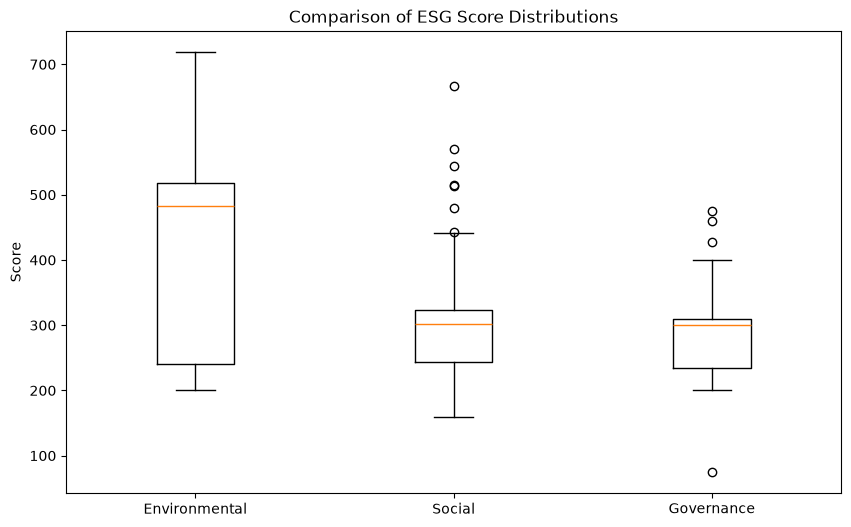

In [11]:
plt.figure(figsize=(10, 6))

plt.boxplot(
    [
        df["environment_score"],
        df["social_score"],
        df["governance_score"]
    ],
    tick_labels=["Environmental", "Social", "Governance"]
)

plt.title("Comparison of ESG Score Distributions")
plt.ylabel("Score")
plt.show()


### Findings

Environmental scores show the widest spread among the three ESG dimensions, indicating greater variation in environmental performance across companies.

Social and Governance scores are more concentrated around their median values, although both contain several potential outliers.

Because the score ranges differ across the ESG dimensions, the raw scores should not be used to directly rank Environmental, Social, and Governance performance.


---

# Section 4
## ESG Performance by Industry

This analysis examines how ESG performance varies across industries.


In [12]:
industry_counts = df["industry"].value_counts()

industry_counts


industry
Technology                            63
Biotechnology                         56
Health Care                           51
Real Estate                           36
Financial Services                    33
Utilities                             30
Banking                               29
Insurance                             27
Electrical Equipment                  27
Retail                                26
Semiconductors                        24
Media                                 23
Hotels Restaurants and Leisure        22
Pharmaceuticals                       21
Machinery                             21
Consumer products                     20
Chemicals                             19
Energy                                19
Life Sciences Tools and Services      16
Food Products                         14
Unknown                               13
Building                              10
Aerospace and Defense                 10
Communications                         9
Metals 

### Industry Sample Size

The number of companies varies considerably across industries. To make industry-level comparisons more meaningful, the analysis focuses on industries represented by at least 10 companies.


In [13]:
industries_10_plus = industry_counts[industry_counts >= 10].index

industry_esg = (
    df[df["industry"].isin(industries_10_plus)]
    .groupby("industry")[
        ["environment_score", "social_score", "governance_score", "total_score"]
    ]
    .mean()
    .round(2)
)

industry_esg


,environment_score,social_score,governance_score,total_score
industry,,,,
Aerospace and Defense,485.00,305.70,299.00,1089.70
Banking,341.48,292.34,264.48,898.31
Biotechnology,306.54,268.86,291.52,866.91
Building,476.70,305.10,292.40,1074.20
Chemicals,463.74,304.37,290.79,1058.89
Consumer products,384.90,285.70,274.95,945.55
Electrical Equipment,381.70,272.11,279.19,933.00
Energy,526.26,316.11,299.89,1142.26
Financial Services,367.64,276.45,265.24,909.33


### Environmental Performance by Industry

The mean Environmental score is compared across industries with at least 10 companies. Records with an unknown industry classification are excluded from this comparison.


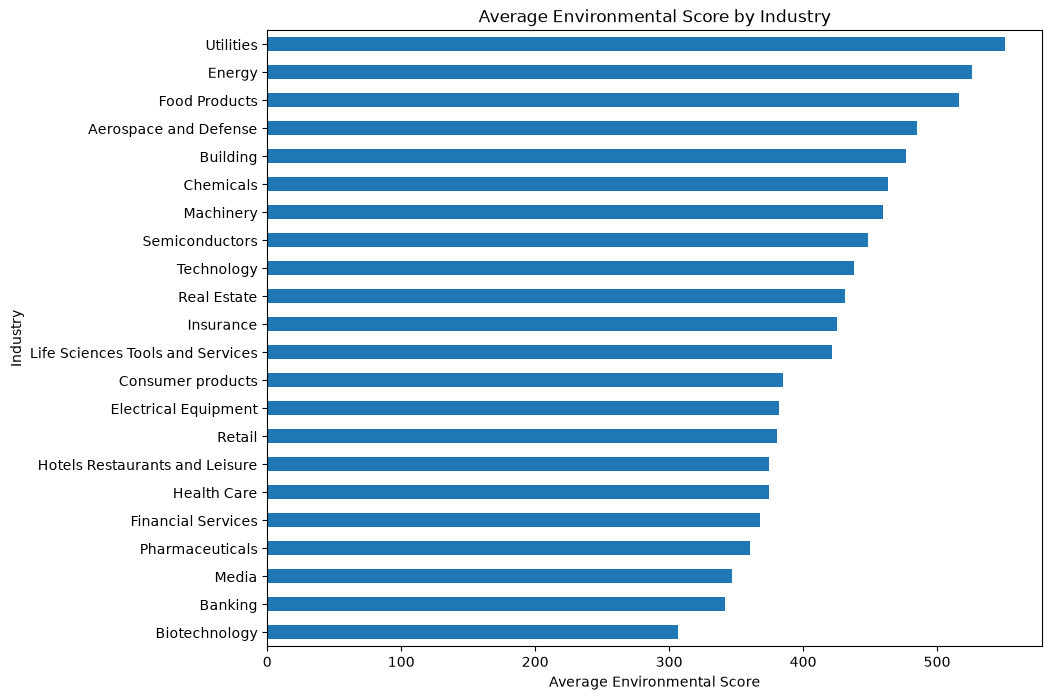

In [14]:
environment_by_industry = (
    industry_esg
    .drop(index="Unknown", errors="ignore")
    ["environment_score"]
    .sort_values()
)

plt.figure(figsize=(10, 8))
environment_by_industry.plot(kind="barh")

plt.title("Average Environmental Score by Industry")
plt.xlabel("Average Environmental Score")
plt.ylabel("Industry")
plt.show()


#### Findings

- Environmental performance varies considerably across industries.
- Utilities has the highest average Environmental score (approximately 551), followed by Energy (approximately 526) and Food Products (approximately 517).
- Biotechnology has the lowest average Environmental score among the industries included in this comparison (approximately 307).
- These results suggest that Environmental scores are not evenly distributed across industries and that industry context may be an important factor when comparing company ESG performance.


### Social Performance by Industry

This analysis compares the average Social score across industries to identify differences in social performance.


In [15]:
social_by_industry = (
    df[df["industry"].isin(industries_10_plus)]
    .groupby("industry")["social_score"]
    .mean()
    .sort_values(ascending=False)
)

social_by_industry


industry
Utilities                           357.400000
Energy                              316.105263
Machinery                           313.666667
Media                               313.000000
Food Products                       311.285714
Technology                          307.904762
Aerospace and Defense               305.700000
Building                            305.100000
Chemicals                           304.368421
Semiconductors                      296.708333
Insurance                           295.666667
Life Sciences Tools and Services    294.500000
Banking                             292.344828
Real Estate                         290.916667
Health Care                         287.431373
Consumer products                   285.700000
Hotels Restaurants and Leisure      283.045455
Financial Services                  276.454545
Retail                              274.961538
Electrical Equipment                272.111111
Pharmaceuticals                     269.666667
Biot

In [16]:
social_by_industry = (
    df[
        (df["industry"].isin(industries_10_plus)) &
        (df["industry"] != "Unknown")
    ]
    .groupby("industry")["social_score"]
    .mean()
    .sort_values(ascending=False)
)

social_by_industry


industry
Utilities                           357.400000
Energy                              316.105263
Machinery                           313.666667
Media                               313.000000
Food Products                       311.285714
Technology                          307.904762
Aerospace and Defense               305.700000
Building                            305.100000
Chemicals                           304.368421
Semiconductors                      296.708333
Insurance                           295.666667
Life Sciences Tools and Services    294.500000
Banking                             292.344828
Real Estate                         290.916667
Health Care                         287.431373
Consumer products                   285.700000
Hotels Restaurants and Leisure      283.045455
Financial Services                  276.454545
Retail                              274.961538
Electrical Equipment                272.111111
Pharmaceuticals                     269.666667
Biot

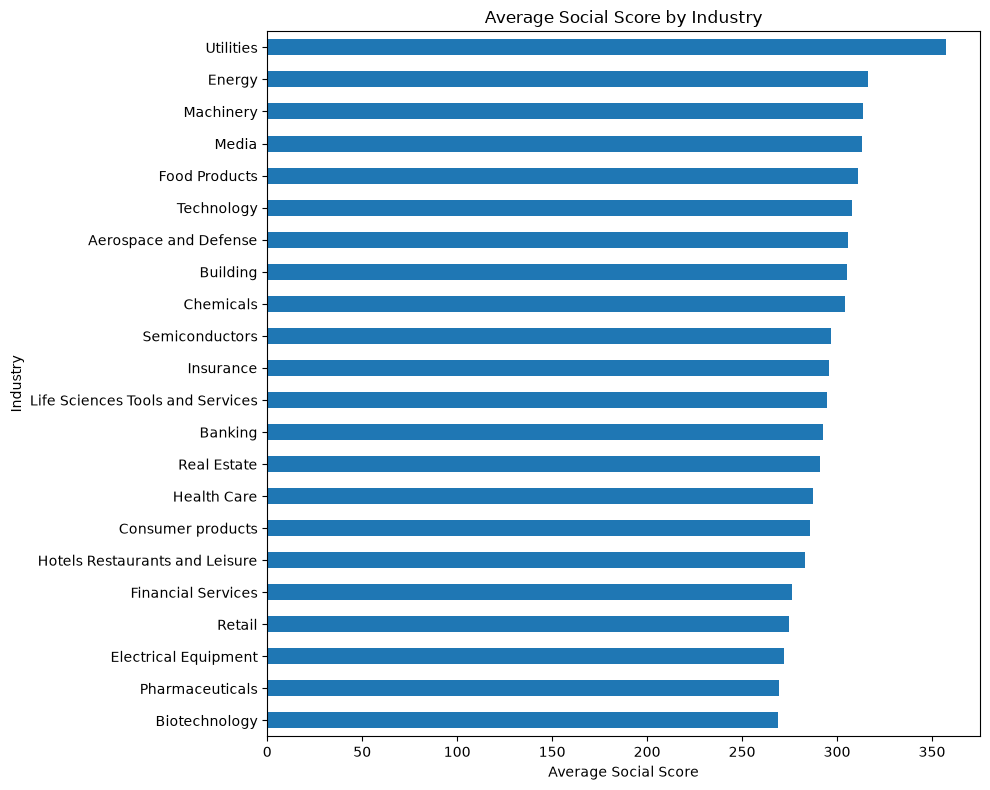

In [17]:
plt.figure(figsize=(10, 8))

social_by_industry.sort_values().plot(kind="barh")

plt.title("Average Social Score by Industry")
plt.xlabel("Average Social Score")
plt.ylabel("Industry")

plt.tight_layout()
plt.show()


#### Findings

- Social performance varies across industries, although the differences are less pronounced than those observed for Environmental scores.
- Utilities has the highest average Social score (approximately 357), followed by Energy (approximately 316).
- Machinery and Media also show relatively high average Social scores.
- Biotechnology has the lowest average Social score among the industries included in this comparison (approximately 269).
- These results indicate that Social performance differs across industries, but the scores are more closely grouped than Environmental scores.


### Governance Performance by Industry

This analysis compares the average Governance score across industries to identify differences in governance performance.


In [18]:
governance_by_industry = (
    df[
        (df["industry"].isin(industries_10_plus)) &
        (df["industry"] != "Unknown")
    ]
    .groupby("industry")["governance_score"]
    .mean()
    .sort_values(ascending=False)
)

governance_by_industry


industry
Food Products                       303.214286
Energy                              299.894737
Aerospace and Defense               299.000000
Building                            292.400000
Biotechnology                       291.517857
Insurance                           291.444444
Chemicals                           290.789474
Semiconductors                      285.416667
Technology                          285.301587
Utilities                           282.266667
Electrical Equipment                279.185185
Life Sciences Tools and Services    277.250000
Health Care                         276.803922
Media                               275.347826
Consumer products                   274.950000
Machinery                           274.809524
Pharmaceuticals                     273.952381
Real Estate                         273.638889
Financial Services                  265.242424
Banking                             264.482759
Retail                              263.307692
Hote

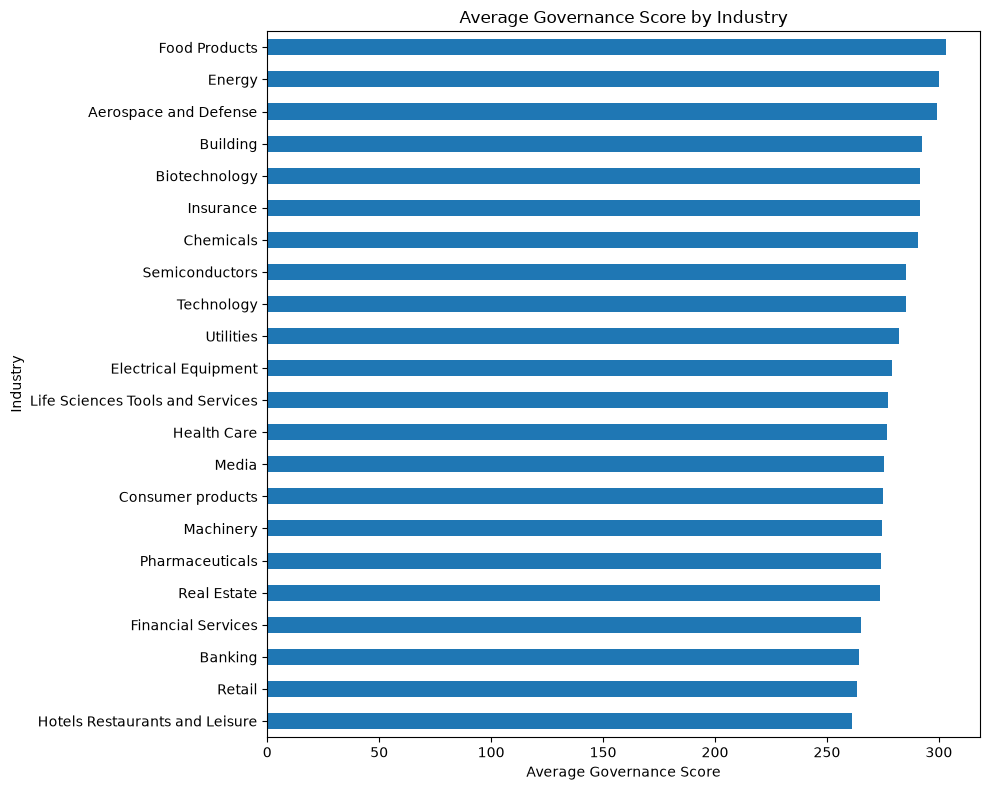

In [19]:
plt.figure(figsize=(10, 8))

governance_by_industry.sort_values().plot(kind="barh")

plt.title("Average Governance Score by Industry")
plt.xlabel("Average Governance Score")
plt.ylabel("Industry")

plt.tight_layout()
plt.show()


### Governance Performance Findings

- Food Products has the highest average Governance score among the industries analysed.
- Energy and Aerospace and Defense also show relatively high average Governance scores.
- Hotels Restaurants and Leisure has the lowest average Governance score.
- Governance performance varies less across industries compared with Environmental performance.
- The industry rankings differ across the Environmental, Social, and Governance dimensions, suggesting that strong performance in one ESG dimension does not necessarily correspond to equally strong performance in the others.


### Total ESG Performance by Industry

The overall ESG performance of each industry is examined using the average total ESG score.
Only industries with at least 10 companies are included to provide more reliable comparisons.


In [20]:
total_by_industry = (
    df[df["industry"].isin(industries_10_plus)]
    .groupby("industry")["total_score"]
    .mean()
    .sort_values(ascending=False)
)

total_by_industry


industry
Utilities                           1190.633333
Energy                              1142.263158
Food Products                       1131.071429
Aerospace and Defense               1089.700000
Building                            1074.200000
Chemicals                           1058.894737
Machinery                           1048.047619
Technology                          1031.317460
Semiconductors                      1030.583333
Insurance                           1012.370370
Real Estate                          995.944444
Life Sciences Tools and Services     993.125000
Consumer products                    945.550000
Health Care                          938.764706
Media                                935.260870
Electrical Equipment                 933.000000
Hotels Restaurants and Leisure       918.863636
Retail                               918.576923
Financial Services                   909.333333
Pharmaceuticals                      903.666667
Banking                        

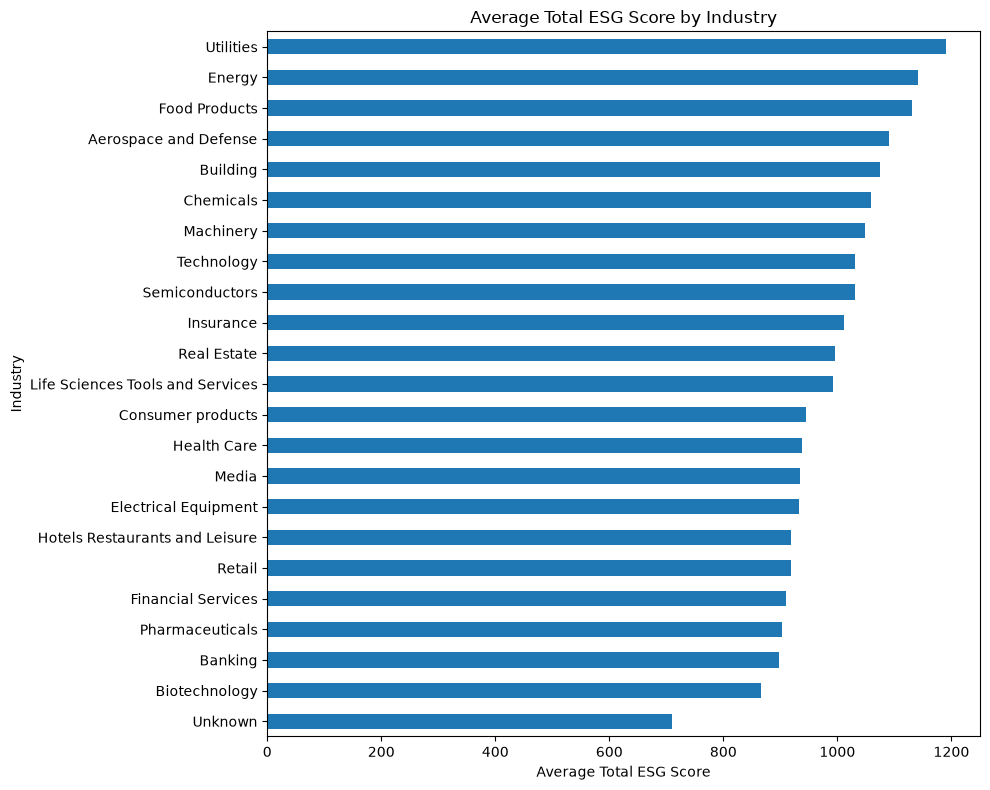

In [21]:
plt.figure(figsize=(10, 8))

total_by_industry.sort_values().plot(kind="barh")

plt.title("Average Total ESG Score by Industry")
plt.xlabel("Average Total ESG Score")
plt.ylabel("Industry")
plt.tight_layout()
plt.show()


### Key Findings

- Utilities recorded the highest average Total ESG Score, followed by Energy and Food Products.
- Environmental performance showed the greatest variation across industries compared with Social and Governance performance.
- Utilities achieved particularly strong average Environmental and Social scores.
- Food Products recorded the highest average Governance score among the industries included in the comparison.
- ESG performance varies across industries, suggesting that industry characteristics may be associated with differences in Environmental, Social, and Governance performance.
- The "Unknown" industry category was not considered when interpreting industry-specific performance because it does not represent a defined industry.


---

# Section 5

## ESG Grades and Levels Analysis

This section examines the distribution of ESG grades and performance levels across companies to understand how companies are classified based on their Environmental, Social, Governance, and overall ESG performance.


In [23]:
grade_columns = [
    "environment_grade",
    "social_grade",
    "governance_grade",
    "total_grade"
]

for column in grade_columns:
    print(f"\n{column}:")
    print(df[column].value_counts())



environment_grade:
environment_grade
A      321
B      255
BB      69
BBB     45
AA      32
Name: count, dtype: int64

social_grade:
social_grade
BB     441
B      262
BBB     13
A        4
CCC      1
AA       1
Name: count, dtype: int64

governance_grade:
governance_grade
BB     434
B      282
BBB      5
C        1
Name: count, dtype: int64

total_grade:
total_grade
BBB    368
B      167
BB     104
A       83
Name: count, dtype: int64


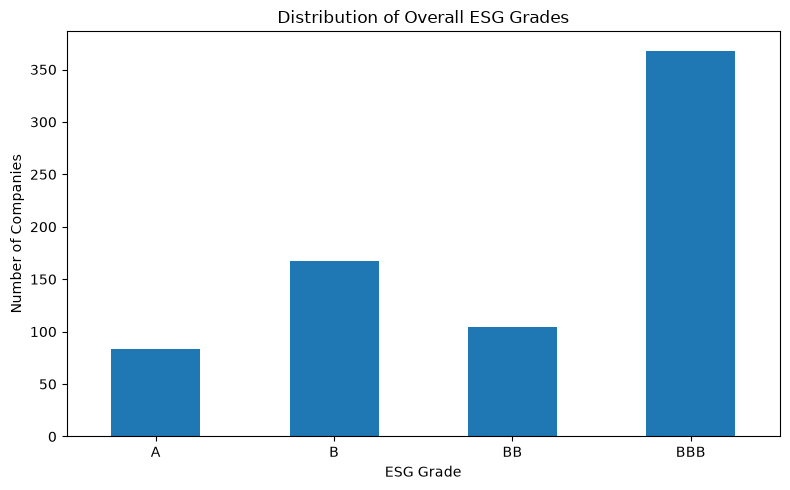

In [24]:
import matplotlib.pyplot as plt

grade_counts = df["total_grade"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
grade_counts.plot(kind="bar")

plt.title("Distribution of Overall ESG Grades")
plt.xlabel("ESG Grade")
plt.ylabel("Number of Companies")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


### ESG Levels Distribution

The distribution of ESG performance levels is examined to show how companies are classified across the Environmental, Social, Governance, and overall ESG dimensions.


In [25]:
level_columns = [
    "environment_level",
    "social_level",
    "governance_level",
    "total_level"
]

for column in level_columns:
    print(f"\n{column}:")
    print(df[column].value_counts())



environment_level:
environment_level
High         366
Medium       324
Excellent     32
Name: count, dtype: int64

social_level:
social_level
Medium       703
High          17
Low            1
Excellent      1
Name: count, dtype: int64

governance_level:
governance_level
Medium    716
High        5
Low         1
Name: count, dtype: int64

total_level:
total_level
High      451
Medium    271
Name: count, dtype: int64


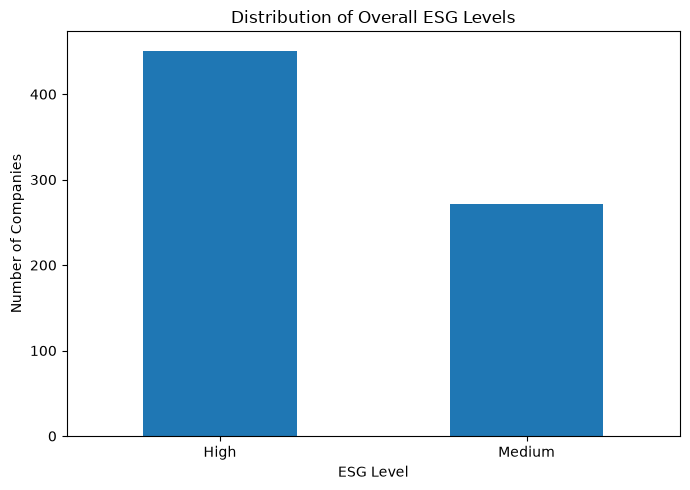

In [26]:
level_counts = df["total_level"].value_counts()

plt.figure(figsize=(7, 5))
level_counts.plot(kind="bar")

plt.title("Distribution of Overall ESG Levels")
plt.xlabel("ESG Level")
plt.ylabel("Number of Companies")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


---

# Section 6

## Relationships Between ESG Dimensions

This section examines the relationships between Environmental, Social, and Governance scores to identify whether the ESG dimensions tend to vary together across companies.


In [22]:
esg_scores = df[
    ["environment_score", "social_score", "governance_score"]
]

correlation_matrix = esg_scores.corr()

correlation_matrix


,environment_score,social_score,governance_score
environment_score,1.000000,0.671817,0.558682
social_score,0.671817,1.000000,0.483364
governance_score,0.558682,0.483364,1.000000


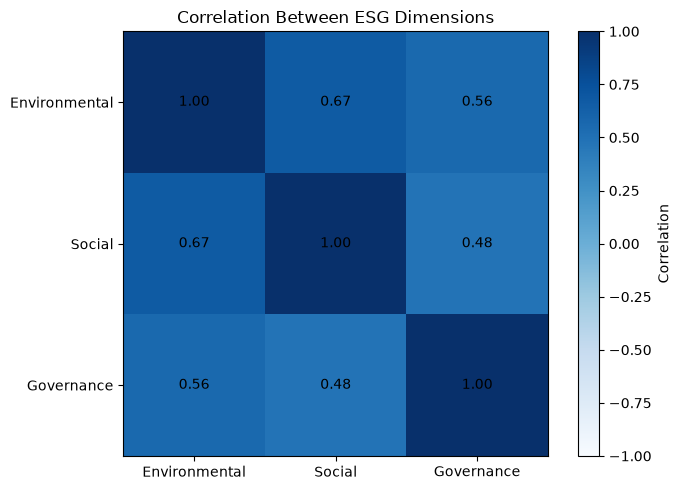

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.imshow(correlation_matrix, cmap="Blues", vmin=-1, vmax=1)

plt.colorbar(label="Correlation")

labels = ["Environmental", "Social", "Governance"]
plt.xticks(range(3), labels)
plt.yticks(range(3), labels)

for i in range(3):
    for j in range(3):
        plt.text(
            j, i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Correlation Between ESG Dimensions")
plt.tight_layout()
plt.show()


### Key Findings

- All three ESG dimensions show positive correlations.
- The strongest relationship is between Environmental and Social scores (0.67).
- Environmental and Governance scores show a moderate positive correlation (0.56).
- Social and Governance scores also show a moderate positive correlation (0.48).
- Overall, companies with stronger performance in one ESG dimension tend to perform better in the other dimensions, although the relationships are not perfect.


---

# Section 7

## Hypothesis Analysis

This section evaluates three hypotheses based on the ESG dataset to determine whether the observed data supports each proposed statement.


### Hypothesis 1: Environmental and Social Performance

**Hypothesis:** Companies with higher Environmental scores tend to have higher Social scores.

The relationship is evaluated using the correlation between Environmental and Social scores.


In [28]:
env_social_corr = df["environment_score"].corr(df["social_score"])

print(f"Environmental-Social correlation: {env_social_corr:.2f}")

if env_social_corr > 0:
    print("Result: Supported")
else:
    print("Result: Not Supported")


Environmental-Social correlation: 0.67
Result: Supported


### Hypothesis 2: ESG Performance Across Industries

**Hypothesis:** Average Total ESG performance differs across industries.

The hypothesis is evaluated by comparing the average Total ESG Score across industries.


In [29]:
industry_total_scores = (
    df.groupby("industry")["total_score"]
    .mean()
    .sort_values(ascending=False)
)

industry_total_scores


industry
Utilities                             1190.633333
Tobacco                               1165.000000
Industrial Conglomerates              1157.000000
Packaging                             1156.000000
Energy                                1142.263158
Food Products                         1131.071429
Distributors                          1109.666667
Aerospace and Defense                 1089.700000
Construction                          1082.666667
Road and Rail                         1076.333333
Building                              1074.200000
Beverages                             1061.000000
Chemicals                             1058.894737
Machinery                             1048.047619
Professional Services                 1047.857143
Technology                            1031.317460
Semiconductors                        1030.583333
Metals and Mining                     1028.333333
Logistics and Transportation          1025.166667
Insurance                             101

**Result: Supported**

Average Total ESG Scores vary across industries. Utilities has one of the highest average Total ESG Scores, while several industries show considerably lower average scores. This indicates that ESG performance differs across industries.


### Hypothesis 3: Environmental Performance Across Industries

**Hypothesis:** Average Environmental performance differs across industries.

The hypothesis is evaluated by comparing the average Environmental Score across industries.


In [30]:
industry_environment_scores = (
    df.groupby("industry")["environment_score"]
    .mean()
    .sort_values(ascending=False)
)

industry_environment_scores


industry
Utilities                             550.966667
Packaging                             536.250000
Industrial Conglomerates              534.666667
Energy                                526.263158
Distributors                          525.000000
Food Products                         516.571429
Tobacco                               510.000000
Construction                          495.333333
Aerospace and Defense                 485.000000
Building                              476.700000
Beverages                             473.250000
Chemicals                             463.736842
Machinery                             459.571429
Road and Rail                         452.833333
Logistics and Transportation          452.333333
Metals and Mining                     450.888889
Semiconductors                        448.458333
Technology                            438.111111
Professional Services                 435.000000
Real Estate                           431.388889
Insurance  

**Result: Supported**

Average Environmental Scores vary considerably across industries. Utilities shows one of the highest average Environmental Scores, while several industries have much lower average scores. This indicates that Environmental performance differs across industries.


---

# Section 8

### Key Insights & EDA Summary

The Exploratory Data Analysis identified several important patterns in the ESG performance of public companies.

- Environmental performance had the highest average score among the three ESG dimensions, followed by Social and Governance performance.
- The strongest relationship was found between Environmental and Social scores, with a positive correlation of 0.67.
- Environmental and Governance scores also showed a positive correlation of 0.56, while Social and Governance scores had a correlation of 0.48.
- ESG performance varied across industries, with some industries achieving considerably higher average Total ESG Scores than others.
- Environmental performance also varied substantially across industries.
- Utilities was among the strongest-performing industries in both Total ESG and Environmental performance.
- Most companies were classified as High or Medium in the overall ESG level.


### Hypothesis Summary

1. **Environmental and Social Performance:** Supported — Environmental and Social scores showed a positive correlation of 0.67.
2. **ESG Performance Across Industries:** Supported — Average Total ESG Scores varied across industries.
3. **Environmental Performance Across Industries:** Supported — Average Environmental Scores varied across industries.

### Conclusion

The analysis indicates that ESG performance is not uniform across companies and industries. The three ESG dimensions are positively related, while industry-level differences are particularly visible in overall ESG and Environmental performance. These findings will be used to guide the development of the Power BI dashboard.
